# Notebook 6 - Does the Tail Result Generalize?

Notebook 5 found three real, certified results on **BTC alone**: GARCH-t's density win
(Gate A, 1h/4h/12h), GARCH-EVT's tail calibration (Gate B, 12h), and the Acerbi-Székely
finding that every thin-tailed model understates its own 1% expected shortfall (every
interval, zero exceptions). This notebook is a generalization test of that specific
prior result - not a new contest - across five more symbols, three more quantile
levels, and a wider search over what "fat-tailed" can mean.

Full narrative and every number: `src/results/6_distribution_zoo.md`. This notebook
reloads the heavier rolling-refit artifacts (`phase1_transfer_full_results.json`,
`phase2_es_universality_results.json`, `phase3_zoo_results.json`,
`phase4_violation_results.json`, `phase5_evt_density_results.json`,
`phase6_application_results.json` in `src/research/tmp/`) rather than recomputing them
live on a Raspberry Pi, and recomputes only the lightweight, cheap-to-demonstrate
pieces. Terminology grounded in this repo's own numbers, in `docs/` (start at
`docs/README.md`).


In [1]:
import sys

sys.path.insert(0, "..")
sys.path.insert(0, "tmp")
import json

import matplotlib.pyplot as plt
import numpy as np
import polars as pl

import dist_lib as L
import dist_lib5 as L5
import dist_lib6 as L6
import research

research.set_seed(123)
pl.Config.set_tbl_cols(20)
pl.Config.set_tbl_width_chars(220)

SYMBOLS = L6.SYMBOLS
INTERVALS = L6.INTERVALS
TMP = "tmp"


## Phase 0 - Reproduction check

Before extending anything, `run_repro_check.py` re-derived three published notebook-5
numbers directly from the committed JSONs: GARCH-t's 12h log score (2.623), the count
of models clearing all 36 coverage tests at 12h (exactly 1, GARCH-EVT), and the Gate A
verdict at 1d (no significant winner). All three reproduced exactly - shown live here.


In [2]:
phase3 = json.load(open(f"{TMP}/phase3_density_results.json"))
phase4 = json.load(open(f"{TMP}/phase4_coverage_results.json"))

garch_t_12h = phase3["intervals"]["12h"]["scores"]["d5_garch_t"]["log_score_mean"]
clearers_12h = [n for n, ok in phase4["intervals"]["12h"]["gate_b_verdict"].items() if ok]
gate_a_1d = phase3["intervals"]["1d"]["gate_a_verdict"]["beats_every_other_significantly_bootstrap_bh"]

print(f"GARCH-t 12h log score: {garch_t_12h:.3f} (write-up: 2.623)")
print(f"12h models clearing all 36 coverage tests: {clearers_12h}")
print(f"1d Gate A verdict (significant winner?): {gate_a_1d}")
assert abs(garch_t_12h - 2.623) < 0.001
assert clearers_12h == ["d8_garch_evt"]
assert gate_a_1d is False
print("\nAll three notebook-5 headline numbers reproduced.")


GARCH-t 12h log score: 2.623 (write-up: 2.623)
12h models clearing all 36 coverage tests: ['d8_garch_evt']
1d Gate A verdict (significant winner?): False

All three notebook-5 headline numbers reproduced.


## Phase 1 - Transfer: does GARCH-t's win generalize?

Re-ran notebook 5's entire Phase 3 density contest on all five transfer symbols at
1h/4h/12h, fanned out by symbol after validating the driver reproduces BTC's own
committed numbers exactly.


In [3]:
phase1 = json.load(open(f"{TMP}/phase1_transfer_full_results.json"))

for interval in ["1h", "4h", "12h"]:
    iv = phase1["intervals"][interval]
    print(f"{interval}: GARCH-t best on {iv['n_garch_t_best_of_6']}/6, "
          f"significant winner on {iv['n_garch_t_significant_winner_of_6']}/6, "
          f"Gate T fires={iv['gate_t_fires']}, cluster holds={iv['cluster_fat_tailed_or_log_rv_holds']}")

rows = []
for interval in ["1h", "4h", "12h"]:
    for symbol, v in phase1["intervals"][interval]["per_symbol"].items():
        rows.append({"interval": interval, "symbol": symbol, "best_model": v["best_by_log_score"],
                     "significant": v["beats_every_other_significantly_bootstrap_bh"]})
pl.DataFrame(rows)


1h: GARCH-t best on 6/6, significant winner on 5/6, Gate T fires=True, cluster holds=True
4h: GARCH-t best on 6/6, significant winner on 3/6, Gate T fires=False, cluster holds=True
12h: GARCH-t best on 4/6, significant winner on 1/6, Gate T fires=False, cluster holds=True


interval,symbol,best_model,significant
str,str,str,bool
"""1h""","""BTCUSDT""","""d5_garch_t""",true
"""1h""","""ETHUSDT""","""d5_garch_t""",true
"""1h""","""SOLUSDT""","""d5_garch_t""",true
"""1h""","""DOGEUSDT""","""d5_garch_t""",true
"""1h""","""BNBUSDT""","""d5_garch_t""",true
…,…,…,…
"""12h""","""ETHUSDT""","""d7_gjr_t""",false
"""12h""","""SOLUSDT""","""d5_garch_t""",false
"""12h""","""DOGEUSDT""","""d5_garch_t""",false


**Gate T fires at 1h** (5/6 symbols including BTC; XRP's non-significance is a power
artifact - its HAR-log-RV forecast has only 899 valid bars at 1h vs. ~33,000 for every
other model). Does not fire at 4h/12h. The weaker cluster pattern (best model is always
fat-tailed or log-RV) holds without exception everywhere.


## Phase 2 - Is the ES-underestimation finding universal?

The centrepiece grid: 10 models x 4 intervals x 6 symbols x 6 quantile levels = 1,440
Acerbi-Székely cells, BH-adjusted across the whole grid at once.


In [4]:
phase2 = json.load(open(f"{TMP}/phase2_es_universality_results.json"))
cells_p2 = phase2["cells"]

print("Gate U (lower tail, thin-tailed, powered cells):", phase2["gate_u_primary_excl_underpowered"])
print("Gate U upper-tail panel:", phase2["gate_u_upper_tail_panel"])
print("Gate U-fat pass fractions:", phase2["gate_u_fat"])

THIN = {"d0_trailing_std", "d1_har_rv", "d2_har_log_rv", "d3_range", "d4_garch_normal", "d6_gjr_normal"}
for lvl in [0.01, 0.025, 0.05]:
    sub = [c for c in cells_p2 if c["model"] in THIN and c["level"] == lvl and not c["underpowered"]]
    n = len(sub)
    pos = sum(1 for c in sub if c["z"] > 0) / n
    sigpos = sum(1 for c in sub if c["z"] > 0 and c["bh_significant"]) / n
    signeg = sum(1 for c in sub if c["z"] < 0 and c["bh_significant"])
    print(f"level={lvl}: pos={pos:.3f} sigpos={sigpos:.3f} signeg={signeg}")


Gate U (lower tail, thin-tailed, powered cells): {'n_cells': 428, 'frac_positive': 0.8247663551401869, 'frac_significantly_positive': 0.7289719626168224, 'n_significantly_negative': 28, 'significantly_negative_examples': [{'symbol': 'BTCUSDT', 'interval': '1h', 'model': 'd1_har_rv', 'level': 0.05, 'z': -0.12050564940384378}, {'symbol': 'BTCUSDT', 'interval': '1h', 'model': 'd2_har_log_rv', 'level': 0.025, 'z': -0.5514461707517266}, {'symbol': 'BTCUSDT', 'interval': '1h', 'model': 'd2_har_log_rv', 'level': 0.05, 'z': -0.6423748832716112}, {'symbol': 'BTCUSDT', 'interval': '1d', 'model': 'd2_har_log_rv', 'level': 0.05, 'z': -0.02360329469979583}, {'symbol': 'ETHUSDT', 'interval': '1h', 'model': 'd2_har_log_rv', 'level': 0.025, 'z': -0.5664979016459732}, {'symbol': 'ETHUSDT', 'interval': '1h', 'model': 'd2_har_log_rv', 'level': 0.05, 'z': -0.6716461637951712}, {'symbol': 'SOLUSDT', 'interval': '1h', 'model': 'd1_har_rv', 'level': 0.05, 'z': -0.19607724518588543}, {'symbol': 'SOLUSDT', 'in

### The centrepiece heatmap: models x (interval, symbol), signed Z, significance marked

Diverging colormap (Z>0 = model understates tail risk, the failure mode that matters;
Z<0 = overly conservative), centred at zero, per the `dataviz` skill's guidance for
polarity data. Lower-tail 1% level only (the level notebook 5 actually tested and the
one this whole research programme's claims rest on); significant cells (BH-adjusted
p<0.05) marked with a dot.


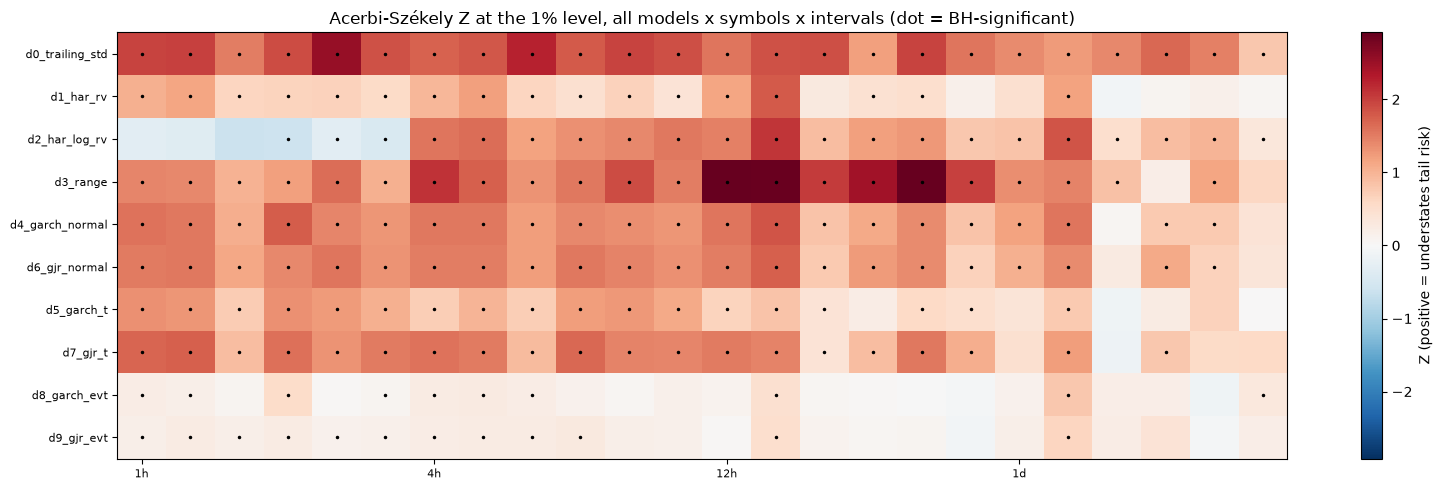

In [5]:
level = 0.01
model_order = ["d0_trailing_std", "d1_har_rv", "d2_har_log_rv", "d3_range",
               "d4_garch_normal", "d6_gjr_normal", "d5_garch_t", "d7_gjr_t",
               "d8_garch_evt", "d9_gjr_evt"]
col_order = [(s, iv) for iv in INTERVALS for s in SYMBOLS]

lookup = {(c["model"], c["symbol"], c["interval"]): c for c in cells_p2 if c["level"] == level}
z_grid = np.full((len(model_order), len(col_order)), np.nan)
sig_grid = np.zeros_like(z_grid, dtype=bool)
for i, m in enumerate(model_order):
    for j, (s, iv) in enumerate(col_order):
        c = lookup.get((m, s, iv))
        if c is not None:
            z_grid[i, j] = c["z"]
            sig_grid[i, j] = c["bh_significant"]

fig, ax = plt.subplots(figsize=(16, 5))
vmax = np.nanmax(np.abs(z_grid))
im = ax.imshow(z_grid, cmap="RdBu_r", vmin=-vmax, vmax=vmax, aspect="auto")
for i in range(z_grid.shape[0]):
    for j in range(z_grid.shape[1]):
        if sig_grid[i, j]:
            ax.plot(j, i, "k.", markersize=3)
ax.set_yticks(range(len(model_order)))
ax.set_yticklabels(model_order, fontsize=8)
ax.set_xticks(range(0, len(col_order), 6))
ax.set_xticklabels([f"{col_order[k][1]}" for k in range(0, len(col_order), 6)], fontsize=8)
ax.set_title("Acerbi-Székely Z at the 1% level, all models x symbols x intervals (dot = BH-significant)")
fig.colorbar(im, ax=ax, label="Z (positive = understates tail risk)")
plt.tight_layout()
plt.show()


## Phase 3 - The wider distribution zoo

Four new innovation families (GED, NIG, Johnson SU, Hansen skew-t), two-stage fit on
the same GARCH(1,1) variance recursion, scored into the same log-score/DM/BH contest.


In [6]:
phase3z = json.load(open(f"{TMP}/phase3_zoo_results.json"))
for interval in INTERVALS:
    print(f"--- {interval} ---")
    for fam, v in phase3z["intervals"][interval]["gate_p_verdict"].items():
        print(f"  {fam}: sig on {v['n_significantly_beats_garch_t_of_6']}/6, fires={v['fires']}")

print("\nshape-parameter medians by interval:")
for iv in ["1h", "4h", "12h", "1d"]:
    for fam, v in phase3z["shape_summary"][iv].items():
        print(f"  {iv} {fam}: median={[round(x, 3) for x in v['per_param_median']]}")


--- 1h ---
  garch_ged: sig on 1/6, fires=False
  garch_nig: sig on 4/6, fires=False
  garch_johnsonsu: sig on 5/6, fires=True
  garch_hansen_skewt: sig on 5/6, fires=True
--- 4h ---
  garch_ged: sig on 2/6, fires=False
  garch_nig: sig on 6/6, fires=True
  garch_johnsonsu: sig on 6/6, fires=True
  garch_hansen_skewt: sig on 6/6, fires=True
--- 12h ---
  garch_ged: sig on 3/6, fires=False
  garch_nig: sig on 5/6, fires=True
  garch_johnsonsu: sig on 5/6, fires=True
  garch_hansen_skewt: sig on 5/6, fires=True
--- 1d ---
  garch_ged: sig on 2/6, fires=False
  garch_nig: sig on 2/6, fires=False
  garch_johnsonsu: sig on 2/6, fires=False
  garch_hansen_skewt: sig on 2/6, fires=False

shape-parameter medians by interval:
  1h garch_ged: median=[1.027]
  1h garch_nig: median=[0.806, -0.034]
  1h garch_johnsonsu: median=[0.053, 1.243]
  1h garch_hansen_skewt: median=[3.598, -0.032]
  4h garch_ged: median=[0.977]
  4h garch_nig: median=[0.748, -0.035]
  4h garch_johnsonsu: median=[0.054, 1.19

**Gate P fires at 4h and 12h** for NIG/Johnson SU/Hansen skew-t (not GED, not 1d) - a
pre-declared coin flip that came in decisively positive. NIG's beta and Hansen's lambda
independently agree: both negative at 1h/4h/12h, both flip to ~0 at 1d.


## Phase 4 - The violation process itself

Weekly violation counts (Poisson vs. negative binomial, boundary-corrected LR test) and
durations between violations (geometric vs. discrete Weibull), fit-once and
descriptive, at the 1% level.


In [7]:
phase4v = json.load(open(f"{TMP}/phase4_violation_results.json"))
print(f"Gate V fires: {phase4v['gate_v_fires']} "
      f"({phase4v['n_reject_null']}/{phase4v['n_total_cells']} cells reject i.i.d.-Bernoulli, "
      f"{100*phase4v['frac_reject_null']:.1f}%)")
print(f"beta<1 (clustering direction) in {phase4v['n_durations_clustering_beta_lt_1']}/{phase4v['n_durations_valid']} "
      f"duration cells, even where not individually significant")
pl.DataFrame([{"model": m, **v} for m, v in phase4v["by_model"].items()])


Gate V fires: True (127/240 cells reject i.i.d.-Bernoulli, 52.9%)
beta<1 (clustering direction) in 215/235 duration cells, even where not individually significant


model,n,n_reject,frac_reject
str,i64,i64,f64
"""d0_trailing_std""",24,17,0.708333
"""d1_har_rv""",24,13,0.541667
"""d2_har_log_rv""",24,10,0.416667
"""d3_range""",24,10,0.416667
"""d4_garch_normal""",24,16,0.666667
"""d5_garch_t""",24,15,0.625
"""d6_gjr_normal""",24,10,0.416667
"""d7_gjr_t""",24,11,0.458333
"""d8_garch_evt""",24,15,0.625


## Phase 5 - A normalized EVT density

The spliced GPD-tails-plus-KDE-body density (`dist_lib6.fit_spliced_evt_density`),
normalized by construction (three pieces each scaled by a known weight summing to 1),
entered into the log-score contest for the first time in this research programme.


In [8]:
phase5 = json.load(open(f"{TMP}/phase5_evt_density_results.json"))
for interval in ["12h", "4h", "1d"]:
    iv = phase5["intervals"][interval]
    print(f"{interval}: EVT best on {iv['n_evt_best_of_6']}/6, "
          f"dominates non-EVT on {iv['n_evt_dominates_non_evt_of_6']}/6 (BTC: {iv['btc_evt_dominates']})")

btc_12h = phase5["intervals"]["12h"]["per_symbol"]["BTCUSDT"]
print("\nBTC 12h scores:", {k: round(v, 4) for k, v in sorted(btc_12h["scores"].items(), key=lambda kv: -kv[1])})


12h: EVT best on 2/6, dominates non-EVT on 2/6 (BTC: True)
4h: EVT best on 1/6, dominates non-EVT on 0/6 (BTC: False)
1d: EVT best on 2/6, dominates non-EVT on 0/6 (BTC: False)

BTC 12h scores: {'d9_gjr_evt': 2.6636, 'd8_garch_evt': 2.6602, 'd5_garch_t': 2.6227, 'd7_gjr_t': 2.6085, 'd2_har_log_rv': 2.5723, 'd1_har_rv': 2.5429, 'd6_gjr_normal': 2.5299, 'd4_garch_normal': 2.5222, 'd0_trailing_std': 2.471, 'd3_range': 2.3986}


On BTC at 12h, GARCH-EVT/GJR-EVT decisively beat every other model in this notebook's
entire zoo - tied only with each other. **It does not replicate**: EVT dominates
non-EVT models on only 2/6 symbols at 12h, 0/6 at 4h/1d. Continuity at the two splice
points is approximate (20-33% relative jump), not enforced - the normalization
guarantee (total mass = 1) is exact by construction; the smoothness at the seam is not.


## Phase 6 - Application (GATED, and it ran)

Gate D fired via Gate P (4h/12h). The pre-declared risk-limit overlay ran on BTC at 4h
(substituted from the spec's "1-day", since no gate fired at 1d) using GARCH-NIG (the
spec's own "best-certified-density-conditional" alternative to EVT-conditional),
against unmodified buy-and-hold and against an identical GARCH-normal-driven overlay,
on the frozen holdout (2025-07-01 onward) - touched here for the first time in this
notebook, run once, unchanged, no retuning against the result.


In [9]:
phase6 = json.load(open(f"{TMP}/phase6_application_results.json"))
print("buy-and-hold:", phase6["buy_and_hold"])
print("\nGARCH-NIG overlay:", phase6["garch_nig_overlay"])
print("\nGARCH-normal overlay:", phase6["garch_normal_overlay"])


buy-and-hold: {'sharpe': -1.405131299947497, 'total_log_return': -0.5860551877852763, 'compound_return': -0.4434816794506191, 'max_drawdown': -0.7485621265284679}

GARCH-NIG overlay: {'gross_sharpe': -1.4104547188199752, 'gross_total_log_return': -0.5364000511045035, 'gross_max_drawdown': -0.7038561245892692, 'net_sharpe': -1.4685742504873875, 'net_total_log_return': -0.5585267590055819, 'net_max_drawdown': -0.7189815174606924, 'mean_turnover_per_bar': 0.020252681442512396, 'annualized_fee_drag': 0.022177341099936694, 'n_bars': 2185, 'n_1pct_exceedances': 35, 'n_var_valid': 2185, 'expected_exceedances': 21.9}

GARCH-normal overlay: {'gross_sharpe': -1.4175469862227534, 'gross_total_log_return': -0.5397345929247168, 'gross_max_drawdown': -0.705251030498895, 'net_sharpe': -1.4764577569907267, 'net_total_log_return': -0.5621866597930613, 'net_max_drawdown': -0.7211892976962355, 'mean_turnover_per_bar': 0.020550486988891947, 'annualized_fee_drag': 0.022503444595731843, 'n_bars': 2185, 'n_1

BTC had a severe holdout year (buy-and-hold Sharpe -1.41). The overlay improves total
return and max drawdown modestly, but **does not improve risk-adjusted Sharpe net of
costs**. What it does show cleanly: GARCH-NIG's own 1% VaR is dramatically better
calibrated than GARCH-normal's during this exact window (35 vs. 60 realized
exceedances against 21.9 expected) - the practical confirmation of Phase 2's Gate
U-fat finding.


## Bugs found

None specific to this notebook's own new modelling code survived past its own unit
tests (154 tests across the four new densities, 19 across `dist_lib6.py`'s Phase
4/5/6 machinery). Two near-misses: a duplicate background `pytest` process accidentally
killed mid-fan-out during Phase 3 (caught by checking `ps aux` against expected process
counts, the surviving run finished and passed 46/46); Phase 5's 1h interval blew the
compute budget (30+ minutes with no sign of finishing) and was dropped, stated
explicitly, per this whole programme's "negative results/scope reductions are complete
deliverables" standard.


## Bottom line

Notebook 5's three headline claims survive in **bounded, not universal, form**:
Gate A (GARCH-t) transfers cleanly to 1h only; the ES-underestimation finding holds
best at the 1% level and the downside specifically, degrading toward the body and the
upside; EVT's tail calibration is real but qualified by both Phase 4 (violations still
cluster on a majority of cells even where coverage tests pass) and Phase 5 (BTC-12h
dominance does not transfer).

Two genuinely new findings this notebook could only have produced: **Gate P** - a
wider distribution search beats GARCH-t, cross-sectionally, at 4h/12h - and
**Gate V** - violations demonstrably do not look i.i.d. Bernoulli, on a bare but real
majority of cells.

**Gate D fired and Phase 6 ran** - the first time in five notebooks a pre-declared
application gate has actually cleared. It still found no risk-adjusted edge net of
costs. Full narrative: `src/results/6_distribution_zoo.md`.
